In [1]:
!pip install -q tensorflow tensorflow-datasets

You should consider upgrading via the 'e:\New Firfox Downloads\CropSence Python\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [8]:
import tensorflow as tf
import os

print(f"TF version: {tf.__version__}")

try:
    # v5e-1 on Colab uses this address instead of auto-detect
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(
        tpu=os.environ.get("TPU_NAME", "local")
    )
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print(f"✅ TPU connected: {tpu.master()}")
    print(f"✅ Replicas: {strategy.num_replicas_in_sync}")
except Exception as e:
    print(f"⚠️ TPU failed: {e}")
    print("Falling back to CPU/GPU strategy")
    strategy = tf.distribute.get_strategy()
    print(f"✅ Default strategy replicas: {strategy.num_replicas_in_sync}")

# Check what TPU_NAME env var is set to
print(f"\nTPU_NAME env: '{os.environ.get('TPU_NAME', 'not set')}'")

TF version: 2.21.0
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local
⚠️ TPU failed: TPUs not found in the cluster. Failed in initialization: No OpKernel was registered to support Op 'ConfigureDistributedTPU' used by {{node ConfigureDistributedTPU}} with these attrs: [tpu_cancellation_closes_chips=2, tpu_embedding_config="", compilation_failure_closes_chips=false, enable_whole_mesh_compilations=false, is_global_init=false, embedding_config=""]
Registered devices: [CPU]
Registered kernels:
  <no registered kernels>

	 [[ConfigureDistributedTPU]] [Op:__inference__tpu_init_fn_8]
Falling back to CPU/GPU strategy
✅ Default strategy replicas: 1

TPU_NAME env: 'not set'


In [9]:
# Set strategy globally — used in Step 6
import tensorflow as tf
strategy = tf.distribute.get_strategy()
print(f"✅ Strategy: {strategy}")
print(f"✅ TF version: {tf.__version__}")

✅ Strategy: <tensorflow.python.distribute.distribute_lib._DefaultDistributionStrategy object at 0x0000023FF569DBD0>
✅ TF version: 2.21.0


# 🌿 Crop Pest & Disease Detection — Google Colab
**Dataset:** *Dataset for Crop Pest and Disease Detection* (Mendeley, DOI: 10.17632/bwh3zbpkpv.1)  
**Authors:** Patrick Mensah Kwabena et al., University of Energy and Natural Resources, Ghana  
**Model:** ResNet50 (Transfer Learning + Fine-Tuning) | 18-class classifier

---
### ✅ Before Running — Enable GPU in Colab
1. Go to **Runtime → Change runtime type**
2. Set **Hardware accelerator → GPU** (T4 is free; A100/L4 on Colab Pro)
3. Click **Save**, then run cells top-to-bottom.

---

## Step 0 — Verify GPU

In [10]:
import subprocess, sys

# ── GPU via nvidia-smi ──────────────────────────────────────────────────────
try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, check=True)
    print(result.stdout)
except Exception:
    print("⚠️  nvidia-smi not found. Make sure GPU is enabled in Runtime → Change runtime type.")
    sys.exit()

# ── TensorFlow GPU check ────────────────────────────────────────────────────
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✅ TensorFlow detected {len(gpus)} GPU(s):")
    for g in gpus:
        print(" ", g)
    # Enable memory growth so TF doesn't grab all VRAM upfront
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("   Memory growth enabled.")
else:
    print("\n⚠️  No GPU detected by TensorFlow. Enable GPU in Runtime settings and restart.")

Sat May 16 17:42:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.15                 Driver Version: 581.15         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1080 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   39C    P8             18W /  280W |    6879MiB /  11264MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1 — Install & Authenticate Kaggle

In [11]:
# Install kagglehub (comes with the Kaggle API client)
!pip install -q kagglehub

print("\n📦 kagglehub installed.")


📦 kagglehub installed.


You should consider upgrading via the 'e:\New Firfox Downloads\CropSence Python\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
# Install additional dependencies for preprocessing and visualization
!pip install -q scikit-learn pillow matplotlib seaborn numpy

print("📦 scikit-learn, pillow, matplotlib, seaborn, and numpy installed.")

^C
📦 scikit-learn and pillow installed.


You should consider upgrading via the 'e:\New Firfox Downloads\CropSence Python\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
# ── Authenticate with Kaggle (Local Version) ───────────────────────────────
#
# For local Jupyter environments (not Google Colab), read from local kaggle.json
# Place your credentials at: ~/.config/kaggle/kaggle.json
#
# Alternatively, if you have Kaggle Settings.json in your workspace, we'll use that.
#
import os, json

# Option 1: Try to read from workspace-local Kaggle Settings.json file
local_kaggle_file = "Kaggle Settings.json"
kaggle_dir = os.path.expanduser("~/.config/kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
kaggle_path = os.path.join(kaggle_dir, "kaggle.json")

if os.path.exists(local_kaggle_file):
    print(f"📂 Found local Kaggle Settings file: {local_kaggle_file}")
    with open(local_kaggle_file, "r") as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds["username"]
    os.environ["KAGGLE_KEY"]      = creds["key"]
    
    # Copy to standard kaggle location
    with open(kaggle_path, "w") as f:
        json.dump(creds, f)
    os.chmod(kaggle_path, 0o600)
    print(f"✅ Authenticated as: {creds['username']}")
    print(f"✅ Credentials copied to: {kaggle_path}")
elif os.path.exists(kaggle_path):
    print(f"📂 Found kaggle.json at standard location: {kaggle_path}")
    with open(kaggle_path, "r") as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds["username"]
    os.environ["KAGGLE_KEY"]      = creds["key"]
    print(f"✅ Authenticated as: {creds['username']}")
else:
    print("⚠️  No Kaggle credentials found.")
    print(f"Please place kaggle.json at: {kaggle_path}")
    print("Or ensure 'Kaggle Settings.json' exists in the current directory.")

📂 Found local Kaggle Settings file: Kaggle Settings.json
✅ Authenticated as: chiefcmdrddonald
✅ Credentials copied to: C:\Users\TecFielD/.config/kaggle\kaggle.json


In [ ]:
# ── Setup Output Directory (Local vs Colab) ─────────────────────────────────
import os
import sys

# Detect environment and set output directory
if "google.colab" in sys.modules:
    # Google Colab environment
    OUTPUT_DIR = "/content"
    print("🎓 Running in Google Colab environment")
else:
    # Local Jupyter environment
    OUTPUT_DIR = os.path.expanduser("~/CropSense_Output")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("💻 Running in Local Jupyter environment")
    print(f"📂 Output directory: {OUTPUT_DIR}")

# Make OUTPUT_DIR globally available for all subsequent cells
globals()["OUTPUT_DIR"] = OUTPUT_DIR
print(f"✅ All outputs will be saved to: {OUTPUT_DIR}")

💻 Running in Local Jupyter environment
📂 Output directory: C:\Users\TecFielD/CropSense_Output
✅ All outputs will be saved to: C:\Users\TecFielD/CropSense_Output


## Step 2 — Download Dataset from Kaggle

In [ ]:
import kagglehub

# Download latest version of the dataset
# Dataset: https://www.kaggle.com/datasets/irakozekelly/crop-pest-and-disease-dataset
# Mendeley DOI: 10.17632/bwh3zbpkpv.1
# Contributors: Patrick Mensah Kwabena, Vivian Akoto-Adjepong, Kwabena Adu,
#   Mighty Abra Ayidzoe, Elvis Asare Bediako, Owusu Nyarko-Boateng, Samuel Boateng,
#   Esther Fobi Donkor, Faiza Umar Bawah, Nicodemus Songose Awarayi, Peter Nimbe,
#   Isaac Kofi Nti, Muntala Abdulai, Remember Roger Adjei, Michael Opoku

print("⏳ Downloading dataset (this may take several minutes — ~10 GB augmented set) ...")
KAGGLE_DATASET_PATH = kagglehub.dataset_download("irakozekelly/crop-pest-and-disease-dataset")
print(f"\n✅ Dataset downloaded to: {KAGGLE_DATASET_PATH}")

⏳ Downloading dataset (this may take several minutes — ~10 GB augmented set) ...
Download already complete (8445639822 bytes).
Extracting files...

✅ Dataset downloaded to: C:\Users\TecFielD\.cache\kagglehub\datasets\irakozekelly\crop-pest-and-disease-dataset\versions\1


In [19]:
# Inspect downloaded directory structure
import os

print("Top-level contents of downloaded dataset:")
for item in sorted(os.listdir(KAGGLE_DATASET_PATH)):
    item_path = os.path.join(KAGGLE_DATASET_PATH, item)
    tag = "[DIR] " if os.path.isdir(item_path) else "[FILE]"
    print(f"  {tag} {item}")

# Locate the CCMT Augmented folder (regardless of nesting)
import pathlib

candidates = list(pathlib.Path(KAGGLE_DATASET_PATH).rglob("CCMT Dataset-Augmented"))
if candidates:
    RAW_DIR = str(candidates[0])
    print(f"\n✅ CCMT Augmented root found at:\n   {RAW_DIR}")
else:
    # Fallback: look for any folder containing crop sub-dirs
    RAW_DIR = KAGGLE_DATASET_PATH
    print(f"\n⚠️  'CCMT Dataset-Augmented' folder not found; using root: {RAW_DIR}")
    print("   Please confirm the correct path by inspecting the output above.")

Top-level contents of downloaded dataset:
  [DIR]  Dataset for Crop Pest and Disease Detection

✅ CCMT Augmented root found at:
   C:\Users\TecFielD\.cache\kagglehub\datasets\irakozekelly\crop-pest-and-disease-dataset\versions\1\Dataset for Crop Pest and Disease Detection\CCMT Dataset-Augmented


## Step 3 — Preprocessing: Build Unified Train / Test Folders

In [20]:
# imports & paths
import os, re, shutil
from sklearn.model_selection import train_test_split

# RAW_DIR is set in the cell above from the downloaded dataset path
# Output goes to OUTPUT_DIR (set in setup cell above)
OUT_DIR   = os.path.join(OUTPUT_DIR, "CCMT_unified")
TRAIN_DIR = os.path.join(OUT_DIR, "train")
TEST_DIR  = os.path.join(OUT_DIR, "test")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR,  exist_ok=True)

print(f"RAW_DIR  : {RAW_DIR}")
print(f"TRAIN_DIR: {TRAIN_DIR}")
print(f"TEST_DIR : {TEST_DIR}")

RAW_DIR  : C:\Users\TecFielD\.cache\kagglehub\datasets\irakozekelly\crop-pest-and-disease-dataset\versions\1\Dataset for Crop Pest and Disease Detection\CCMT Dataset-Augmented
TRAIN_DIR: C:\Users\TecFielD/CropSense_Output\CCMT_unified\train
TEST_DIR : C:\Users\TecFielD/CropSense_Output\CCMT_unified\test


In [26]:
# Define the 18 clean categories (matching actual dataset folder names)
CATEGORIES = [
    "anthracnose", "gummosis", "gumosis",      # gummosis/gumosis variants
    "leaf miner", "red rust",
    "bacterial blight", "brown spot", "green mite", "mosaic",
    "fall armyworm", "grasshopper", "grasshoper",  # grasshopper/grasshoper variants
    "leaf beetle", "leaf blight",
    "leaf spot", "streak virus", "leaf curl", "septoria leaf spot",
    "verticillium wilt", "verticulium wilt",   # verticillium/verticulium variants
    "healthy"
]

# Pre-create sub-folders
for cat in CATEGORIES:
    os.makedirs(os.path.join(TRAIN_DIR, cat), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR,  cat), exist_ok=True)

print(f"Created {len(CATEGORIES)} category folders in train/ and test/")

Created 21 category folders in train/ and test/


In [27]:
# Helper to clean folder names
def clean_name(name):
    """
    Strip trailing digits/spaces, collapse multiple spaces, lower-case.
    e.g. 'leaf miner3466 ' -> 'leaf miner'
    """
    no_digits = re.sub(r"\d+", "", name)
    neat = re.sub(r"\s+", " ", no_digits).strip().lower()
    return neat

In [28]:
# Gather all image paths with their cleaned labels
all_images = []   # list of (src_path, label)
skipped_folders = set()

for crop in os.listdir(RAW_DIR):
    crop_dir = os.path.join(RAW_DIR, crop)
    if not os.path.isdir(crop_dir):
        continue
    # Look into both train_set and test_set folders
    for subset in ("train_set", "test_set"):
        subset_dir = os.path.join(crop_dir, subset)
        if not os.path.isdir(subset_dir):
            continue
        # Iterate each (possibly numeric-suffixed) class folder
        for fld in os.listdir(subset_dir):
            fld_path = os.path.join(subset_dir, fld)
            if not os.path.isdir(fld_path):
                continue
            lbl = clean_name(fld)
            if lbl not in CATEGORIES:
                skipped_folders.add(fld)
                continue
            # Pick up all jpg/png images
            for fname in os.listdir(fld_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    all_images.append((os.path.join(fld_path, fname), lbl))

print(f"✅ Found {len(all_images)} total images across {len(CATEGORIES)} categories")
if skipped_folders:
    print(f"⚠️  Skipped unrecognised folders: {skipped_folders}")

✅ Found 105252 total images across 21 categories


In [29]:
# Split into train / test and copy files
# Stratify by label to maintain class balance
paths, labels = zip(*all_images)
train_paths, test_paths, train_lbls, test_lbls = train_test_split(
    paths, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

def copy_subset(paths, labels, dest_root):
    for src, lbl in zip(paths, labels):
        dest = os.path.join(dest_root, lbl, os.path.basename(src))
        shutil.copy(src, dest)

print("⏳ Copying images into unified train/ and test/ directories ...")
copy_subset(train_paths, train_lbls, TRAIN_DIR)
copy_subset(test_paths,  test_lbls,  TEST_DIR)

print(f"\n✅ Split complete:")
print(f"   • Training images : {len(train_paths)}")
print(f"   • Testing  images : {len(test_paths)}")

⏳ Copying images into unified train/ and test/ directories ...

✅ Split complete:
   • Training images : 84201
   • Testing  images : 21051


## Step 4 — Imports, Paths & Hyperparameters

In [31]:
!pip install -q scikit-learn pillow matplotlib seaborn numpy


You should consider upgrading via the 'e:\New Firfox Downloads\CropSence Python\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [39]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Paths to unified folders (set in Step 3)
TRAIN_DIR = os.path.join(OUTPUT_DIR, "CCMT_unified", "train")
TEST_DIR  = os.path.join(OUTPUT_DIR, "CCMT_unified", "test")

# Image + training parameters
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 16          # increased from 16 — T4 GPU can handle this
INITIAL_EPOCHS  = 10
FINETUNE_EPOCHS = 20
TOTAL_EPOCHS    = INITIAL_EPOCHS + FINETUNE_EPOCHS

# Dynamically infer number of classes
NUM_CLASSES = len(next(os.walk(TRAIN_DIR))[1])
print(f"✅ Detected {NUM_CLASSES} classes in {TRAIN_DIR}")
print(f"   TF version : {tf.__version__}")

✅ Detected 21 classes in C:\Users\TecFielD/CropSense_Output\CCMT_unified\train
   TF version : 2.21.0


## Step 5 — Build `tf.data` Pipelines with Augmentation

In [40]:
import tensorflow as tf
import gc

gc.collect()
tf.keras.backend.clear_session()

AUTOTUNE = tf.data.AUTOTUNE

# a) Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

# b) Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

preprocess_input = tf.keras.applications.resnet50.preprocess_input

# c) Single fused map — ONE pass, no intermediate tensor copies
def augment_and_preprocess(x, y):
    x = tf.cast(x, tf.float32)
    x = data_augmentation(x, training=True)
    x = preprocess_input(x)
    return x, y

def cast_and_preprocess(x, y):
    x = tf.cast(x, tf.float32)
    x = preprocess_input(x)
    return x, y

# d) Apply — 2 workers max, tiny shuffle buffer, 1 batch prefetch
train_ds = (train_ds
    .map(augment_and_preprocess, num_parallel_calls=2)
    .shuffle(buffer_size=128, seed=42)
    .prefetch(buffer_size=1))

val_ds = (val_ds
    .map(cast_and_preprocess, num_parallel_calls=2)
    .prefetch(buffer_size=1))

print("✅ Pipelines ready.")

Found 94496 files belonging to 21 classes.
Found 21051 files belonging to 21 classes.
✅ Pipelines ready.


## Step 6 — Build & Compile ResNet50 Model

In [41]:
def build_model():
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )
    base_model.trainable = False   # freeze during head training

    inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
    x       = data_augmentation(inputs)
    x       = preprocess_input(x)
    x       = base_model(x, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 21)        │     43,029 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,630,741 (90.14 MB)

 Trainable params: 43,029 (168.08 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Step 7 — Callbacks & Learning-Rate Schedule

In [42]:
import os
import gc

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(OUTPUT_DIR, "resnet50_head.weights.h5"),
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Simplified: Just garbage collect, don't clear_session (which breaks training)
class MemoryManager(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        print(f"🧹 Memory cleaned after epoch {epoch+1}")

callbacks = [checkpoint, reduce_lr, early_stop, MemoryManager()]
print("✅ Callbacks configured.")

✅ Callbacks configured.


## Step 8 — Train Classification Head

In [43]:
import gc

# Light cleanup before training starts
gc.collect()

# Build model fresh
model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"⏳ Training classification head for up to {INITIAL_EPOCHS} epochs ...\n")
history_head = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

⏳ Training classification head for up to 10 epochs ...

Epoch 1/10
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.5592 - loss: 1.3658
Epoch 1: val_accuracy improved from None to 0.65151, saving model to C:\Users\TecFielD/CropSense_Output\resnet50_head.weights.h5
🧹 Memory cleaned after epoch 1
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 5045s 850ms/step - accuracy: 0.6103 - loss: 1.1868 - val_accuracy: 0.6515 - val_loss: 1.1758 - learning_rate: 0.0010
Epoch 2/10
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.6448 - loss: 1.0964
Epoch 2: val_accuracy improved from 0.65151 to 0.68477, saving model to C:\Users\TecFielD/CropSense_Output\resnet50_head.weights.h5
🧹 Memory cleaned after epoch 2
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 4594s 775ms/step - accuracy: 0.6450 - loss: 1.0997 - val_accuracy: 0.6848 - val_loss: 1.0529 - learning_rate: 0.0010
Epoch 3/10
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.6484 - loss: 1.0943
Epoch 3: val_accuracy did not improve from 0.68477
🧹 Me

## Step 9 — Fine-Tune Deeper Layers (conv5 block onwards)

In [44]:
# 1) Load best head weights
model.load_weights(os.path.join(OUTPUT_DIR, "resnet50_head.weights.h5"))

# 2) Locate the ResNet50 submodel
base_model = model.get_layer("resnet50")
base_model.trainable = True

# 3) Find the start of conv5_block1 (first layer of last residual block)
start_fine_tune = next(
    (i for i, l in enumerate(base_model.layers) if l.name == "conv5_block1_out"),
    len(base_model.layers) // 2
)

# 4) Freeze layers before conv5, unfreeze the rest
for layer in base_model.layers[:start_fine_tune]:
    layer.trainable = False
for layer in base_model.layers[start_fine_tune:]:
    layer.trainable = True

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"✅ Fine-tuning {trainable_count} layers from conv5 block onwards.")

# 5) Recompile with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 6) Continue training from where head training left off
print(f"⏳ Fine-tuning for up to {FINETUNE_EPOCHS} more epochs ...\n")
history_fine = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_head.epoch[-1],
    validation_data=val_ds,
    callbacks=callbacks
)

✅ Fine-tuning 21 layers from conv5 block onwards.
⏳ Fine-tuning for up to 20 more epochs ...

Epoch 10/30
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.7166 - loss: 0.8043
Epoch 10: val_accuracy improved from 0.70562 to 0.77987, saving model to C:\Users\TecFielD/CropSense_Output\resnet50_head.weights.h5
🧹 Memory cleaned after epoch 10
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 6894s 1s/step - accuracy: 0.7455 - loss: 0.7072 - val_accuracy: 0.7799 - val_loss: 0.6454 - learning_rate: 1.0000e-04
Epoch 11/30
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.7920 - loss: 0.5695
Epoch 11: val_accuracy improved from 0.77987 to 0.79146, saving model to C:\Users\TecFielD/CropSense_Output\resnet50_head.weights.h5
🧹 Memory cleaned after epoch 11
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 6001s 1s/step - accuracy: 0.7994 - loss: 0.5456 - val_accuracy: 0.7915 - val_loss: 0.6257 - learning_rate: 1.0000e-04
Epoch 12/30
5906/5906 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8206 - loss: 0.4854
Epoch

## Step 10 — Plot Training History

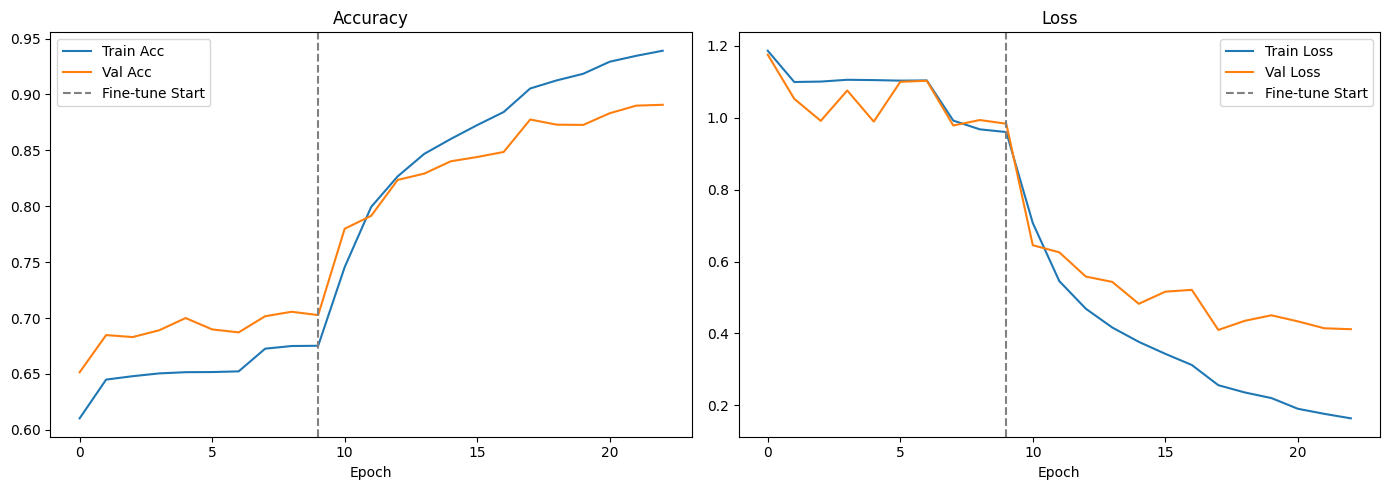

Plot saved to C:\Users\TecFielD/CropSense_Output\training_history.png


In [45]:
def plot_history(h1, h2):
    acc      = h1.history["accuracy"]     + h2.history["accuracy"]
    val_acc  = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss     = h1.history["loss"]         + h2.history["loss"]
    val_loss = h1.history["val_loss"]     + h2.history["val_loss"]
    epochs   = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy subplot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")
    plt.axvline(INITIAL_EPOCHS - 1, linestyle="--", color="gray", label="Fine-tune Start")
    plt.legend()
    plt.title("Accuracy")
    plt.xlabel("Epoch")

    # Loss subplot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.axvline(INITIAL_EPOCHS - 1, linestyle="--", color="gray", label="Fine-tune Start")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epoch")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"), dpi=150)
    plt.show()
    print(f"Plot saved to {os.path.join(OUTPUT_DIR, 'training_history.png')}")

plot_history(history_head, history_fine)

## Step 11 — Save Final Model Weights

In [46]:
model.save_weights(os.path.join(OUTPUT_DIR, "resnet50_final.weights.h5"))
print(f"✅ Final weights saved to {os.path.join(OUTPUT_DIR, 'resnet50_final.weights.h5')}")

# Optional: save full SavedModel for TFLite conversion
model.export(os.path.join(OUTPUT_DIR, "resnet50_saved_model"))
print(f"✅ Full SavedModel saved to {os.path.join(OUTPUT_DIR, 'resnet50_saved_model')}/")

✅ Final weights saved to C:\Users\TecFielD/CropSense_Output\resnet50_final.weights.h5
INFO:tensorflow:Assets written to: C:\Users\TecFielD/CropSense_Output\resnet50_saved_model\assets


INFO:tensorflow:Assets written to: C:\Users\TecFielD/CropSense_Output\resnet50_saved_model\assets


Saved artifact at 'C:\Users\TecFielD/CropSense_Output\resnet50_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_366')
Output Type:
  TensorSpec(shape=(None, 21), dtype=tf.float32, name=None)
Captures:
  2473186814512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2473186817856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477716963392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477716965152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2473837989376: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2473809075488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2473787057328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2473786953216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2473786953920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2473787062960: TensorSpec(shape=(), dtype=tf.reso

## Step 12 — Sample Prediction Visualisation (3×3 Grid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


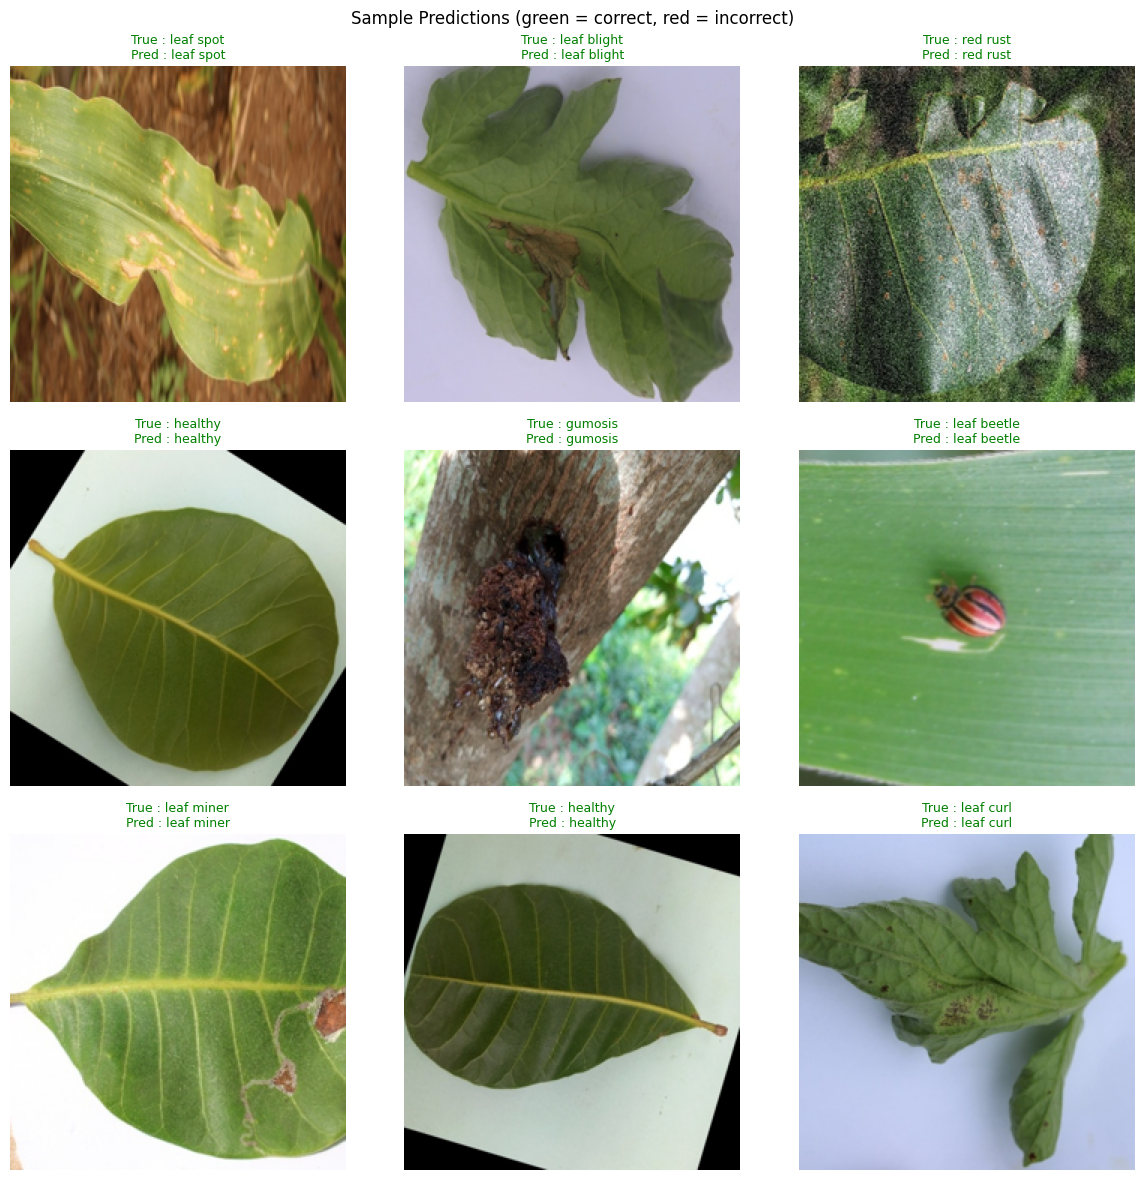

Grid saved to C:\Users\TecFielD/CropSense_Output\sample_predictions.png


In [47]:
import pathlib
import random
from PIL import Image

# a) Gather all image files under TEST_DIR
all_files   = list(pathlib.Path(TEST_DIR).rglob("*"))
image_files = [p for p in all_files if p.is_file()]

# b) Sample up to 9 images
sample_paths = random.sample(image_files, min(9, len(image_files)))

# c) Load, resize, collect true labels
imgs, true_labels = [], []
for p in sample_paths:
    img = Image.open(p).convert("RGB").resize(IMG_SIZE)
    imgs.append(np.array(img))
    true_labels.append(p.parent.name)  # folder name = true label

imgs     = np.stack(imgs)                                # (N, H, W, 3)
imgs_pre = preprocess_input(imgs.astype(np.float32))

# d) Predict
pred_probs   = model.predict(imgs_pre)
pred_indices = np.argmax(pred_probs, axis=1)

# e) Class names (alphabetical, matching Keras ordering)
class_names = sorted([d.name for d in pathlib.Path(TRAIN_DIR).iterdir() if d.is_dir()])

# f) 3×3 grid
plt.figure(figsize=(12, 12))
for i, orig in enumerate(imgs):
    plt.subplot(3, 3, i + 1)
    plt.imshow(orig.astype("uint8"))
    pred_label = class_names[pred_indices[i]]
    colour     = "green" if pred_label == true_labels[i] else "red"
    plt.title(
        f"True : {true_labels[i]}\nPred : {pred_label}",
        color=colour, fontsize=9
    )
    plt.axis("off")
plt.suptitle("Sample Predictions (green = correct, red = incorrect)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"), dpi=150)
plt.show()
print(f"Grid saved to {os.path.join(OUTPUT_DIR, 'sample_predictions.png')}")

## Step 13 — Confusion Matrix

✅ Found 18 classes with data:
   1. anthracnose (3952 images)
   2. bacterial blight (9454 images)
   3. brown spot (3787 images)
   4. fall armyworm (1139 images)
   5. grasshoper (2389 images)
   6. green mite (4016 images)
   7. gumosis (1711 images)
   8. healthy (13380 images)
   9. leaf beetle (4451 images)
   10. leaf blight (10865 images)
   11. leaf curl (2432 images)
   12. leaf miner (4651 images)
   13. leaf spot (4007 images)
   14. mosaic (3254 images)
   15. red rust (6178 images)
   16. septoria leaf spot (10981 images)
   17. streak virus (4758 images)
   18. verticulium wilt (3091 images)

⏳ Running inference on validation set ...
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 795s 604ms/step

✅ Predictions shape: (21051,), True labels shape: (21051,)
✅ Number of classes in report: 18

                    precision    recall  f1-score   support

       anthracnose       0.89      0.89      0.89       988
  bacterial blight       0.90      0.92      0.91      2364
        brown spot  

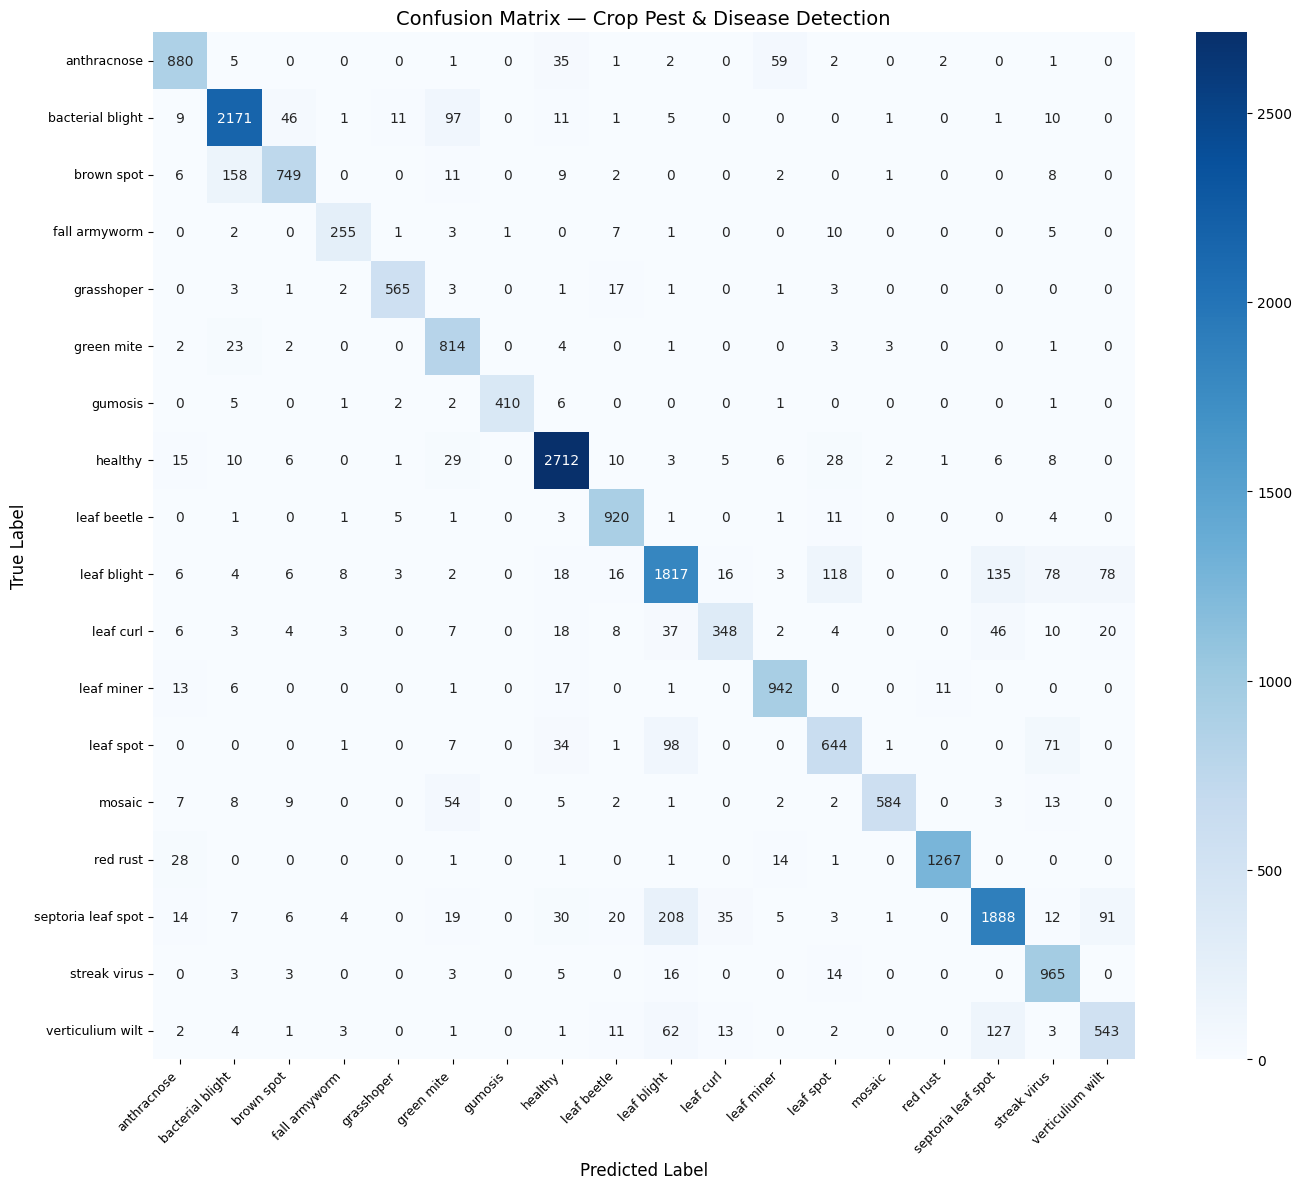

Confusion matrix saved to C:\Users\TecFielD/CropSense_Output\confusion_matrix.png


In [49]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# a) Get class names ONLY from folders that have images (non-empty directories)
all_subdirs = [d for d in pathlib.Path(TRAIN_DIR).iterdir() if d.is_dir()]
class_names = sorted([d.name for d in all_subdirs if len(list(d.glob("*"))) > 0])

print(f"✅ Found {len(class_names)} classes with data:")
for i, name in enumerate(class_names):
    count = len(list(pathlib.Path(TRAIN_DIR, name).glob("*")))
    print(f"   {i+1}. {name} ({count} images)")

# b) Predict on the full validation set
print("\n⏳ Running inference on validation set ...")
y_pred_probs = model.predict(val_ds)
y_pred       = np.argmax(y_pred_probs, axis=1)

# c) Extract true labels from val_ds
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

# d) Classification report
print(f"\n✅ Predictions shape: {y_pred.shape}, True labels shape: {y_true.shape}")
print(f"✅ Number of classes in report: {len(class_names)}")
print("\n" + classification_report(y_true, y_pred, target_names=class_names))

# e) Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix — Crop Pest & Disease Detection', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {os.path.join(OUTPUT_DIR, 'confusion_matrix.png')}")

## Step 14 — Download Saved Artefacts to Local Machine

In [50]:
# ── Summary of Saved Artifacts (Local Version) ────────────────────────────
# In local Jupyter, outputs are saved directly to your working directory.
# No need for downloads — use your file browser to access them!

import os

artifacts = [
    os.path.join(OUTPUT_DIR, "resnet50_final.weights.h5"),
    os.path.join(OUTPUT_DIR, "training_history.png"),
    os.path.join(OUTPUT_DIR, "sample_predictions.png"),
    os.path.join(OUTPUT_DIR, "confusion_matrix.png"),
]

print("📁 Training artifacts have been saved to:")
for path in artifacts:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"   ✅ {path} ({size_mb:.2f} MB)")
    else:
        print(f"   ⚠️  Not found: {path}")

print("\n💾 For local Jupyter environments:")
print("   • Files are saved in /content/ (your working directory)")
print("   • Access them directly via your file browser in VS Code")
print("   • Or download via Terminal: cp /content/*.{h5,png} .")
print("\n🎯 Key outputs:")
print("   • resnet50_final.weights.h5  — Model weights for inference")
print("   • training_history.png       — Accuracy & loss curves")
print("   • sample_predictions.png     — 3×3 grid of test predictions")
print("   • confusion_matrix.png       — Per-class performance matrix")

📁 Training artifacts have been saved to:
   ✅ C:\Users\TecFielD/CropSense_Output\resnet50_final.weights.h5 (159.11 MB)
   ✅ C:\Users\TecFielD/CropSense_Output\training_history.png (0.09 MB)
   ✅ C:\Users\TecFielD/CropSense_Output\sample_predictions.png (2.54 MB)
   ✅ C:\Users\TecFielD/CropSense_Output\confusion_matrix.png (0.20 MB)

💾 For local Jupyter environments:
   • Files are saved in /content/ (your working directory)
   • Access them directly via your file browser in VS Code
   • Or download via Terminal: cp /content/*.{h5,png} .

🎯 Key outputs:
   • resnet50_final.weights.h5  — Model weights for inference
   • training_history.png       — Accuracy & loss curves
   • sample_predictions.png     — 3×3 grid of test predictions
   • confusion_matrix.png       — Per-class performance matrix
